# Event Contract Mispricing via Options-Implied Probabilities

Thin driver for the `kalshi_arb` package. All logic lives in the package;
this notebook only orchestrates and plots. Parameters/assumptions are
documented in `../ASSUMPTIONS.md` and centralized in `kalshi_arb/config.py`.

Pipeline: **io → cleaning → vol → pricing → density → signals → backtest → metrics** (+ `hedging`).

Strategy is the **risk-managed** variant (`MAX_LOTS_PER_BUCKET = 1`, no pyramiding).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # import kalshi_arb from repo root
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from kalshi_arb import pipeline, run, config
from kalshi_arb.extract import kalshi as kalshi_src
from kalshi_arb.transform import density, buckets
from kalshi_arb.strategy import signals, backtest, metrics, hedging
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 20)

## 1. Build the cleaned + priced option chain (steps 2–4)

In [2]:
chain = pipeline.build_chain(save=True)   # clean → smooth vols → BSM (pure model price)
kalshi = kalshi_src.load_kalshi()
chain[['quote','option_type','strike','forward','IV','LSQ_Vol','Mid','BSM']].head()

[clean] dropped 3282 rows on 18 quote date(s) whose only available expiry rolled to next year (e.g. 2022-12-19..2023-12-29)
[clean] dropped 3051 rows violating no-arbitrage price bounds (stale deep-ITM quotes: mid outside [intrinsic, upper])


[clean] 344720 -> 305976 rows | IV missing 4148 -> 0


[price] MAE=1.93  RMSE=3.77  n=305917
[save] C:\HDD\Stevens\Semester 8 Submissions\FE800\FE800 Final Submission\kalshi_stat_arb\artifacts\clean_chain.parquet


,quote,option_type,strike,forward,IV,LSQ_Vol,Mid,BSM
0,2022-01-03,c,2100.0,4771.570065,0.4206,0.433385,2669.45,2665.224363
1,2022-01-03,c,2200.0,4771.570065,0.4121,0.433385,2572.65,2571.083479
2,2022-01-03,c,2300.0,4771.570065,0.4033,0.433385,2476.10,2478.139022
3,2022-01-03,p,2400.0,4771.570065,0.4583,0.433385,27.20,33.500726
4,2022-01-03,c,2400.0,4771.570065,0.3942,0.433385,2379.90,2386.534293


## 2. Risk-neutral densities (step 5)
Breeden–Litzenberger (primary) vs GBM. The BL density is built on a wide strike
grid with flat-vol extrapolation and is **not** renormalized to 1.

BL density mass: 1.0  breach: 0.028


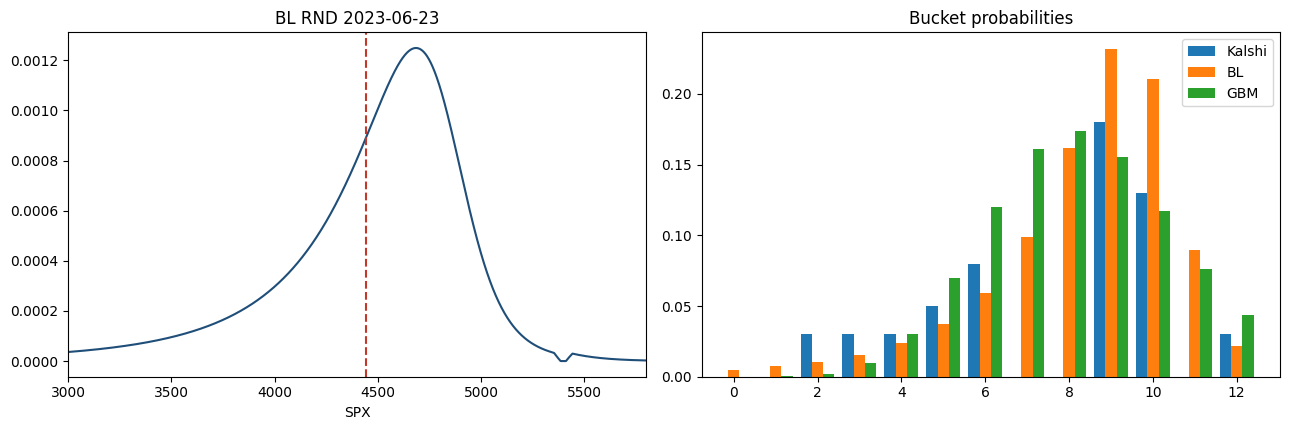

In [3]:
date = pd.Timestamp('2023-06-23'); day = chain[chain['quote']==date]
g, d = density.bl_density(day); F = day['forward'].iloc[0]
buckets = list(kalshi[2023]['price'].columns)
bl = density.bl_pmf(day, buckets); gb = density.gbm_pmf(day, buckets)
kp = kalshi[2023]['price'].reindex([date]).iloc[0] / 100
print('BL density mass:', round(np.trapz(d, g), 3), ' breach:', round(1-sum(bl.values()), 3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(g, d, color='#1f4e79'); ax[0].axvline(F, color='#c0392b', ls='--')
ax[0].set_xlim(3000, 5800); ax[0].set_title(f'BL RND {date.date()}'); ax[0].set_xlabel('SPX')
x = np.arange(len(buckets)); w = 0.27
ax[1].bar(x-w, kp.values, w, label='Kalshi'); ax[1].bar(x, [bl[b] for b in buckets], w, label='BL')
ax[1].bar(x+w, [gb[b] for b in buckets], w, label='GBM'); ax[1].legend(); ax[1].set_title('Bucket probabilities')
plt.tight_layout(); plt.show()

## 3. Full backtest sweep (steps 6–8)
BL & GBM × {2022, 2023, 2024} × {both, buy-only, sell-only}. Metrics are
252-annualized consistently for strategy and benchmark; drawdown is on the
strategy; settlement uses the true year-end S&P 500 close.

In [4]:
table, results, pmf = run.full(chain=chain, kalshi=kalshi, verbose=False)
cols = ['year','model','side','ann_return','ann_vol','sharpe','ann_return_ex_apy','max_dd',
        'alpha_ann','alpha_t','beta','beta_t','model_rho','n_trades','settlement','final_value']
config.ARTIFACT_DIR.mkdir(exist_ok=True)
table[cols].to_csv(config.ARTIFACT_DIR / 'results_table.csv', index=False)
table[cols]

,year,model,side,ann_return,ann_vol,sharpe,ann_return_ex_apy,max_dd,alpha_ann,alpha_t,beta,beta_t,model_rho,n_trades,settlement,final_value
0,2022,BL,both,16.92,6.60,1.99,13.89,-1.60,13.19,1.83,0.019,0.67,0.13,100,8.0,226.55
1,2022,BL,buy,4.49,3.99,0.19,1.12,-1.37,0.75,0.23,0.007,0.47,0.25,13,8.0,209.02
2,2022,BL,sell,5.82,4.35,0.48,2.48,-2.94,2.11,0.56,0.035,1.97,0.14,12,-8.0,209.85
3,2023,BL,both,11.87,3.61,2.25,8.40,-3.14,7.50,2.09,0.032,2.71,0.19,81,8.0,225.47
4,2023,BL,buy,5.21,2.02,0.73,1.68,-0.66,1.38,0.70,0.004,0.48,0.39,9,8.0,210.58
5,2023,BL,sell,7.66,3.39,1.15,4.09,-3.14,3.32,1.06,0.031,2.35,0.28,13,-8.0,209.65
6,2024,BL,both,7.03,3.05,1.08,3.62,-1.18,3.15,1.05,0.006,0.46,0.19,39,0.0,213.74
7,2024,BL,buy,1.55,2.10,-1.05,-1.99,-1.39,-2.21,-1.02,0.001,0.04,0.43,7,0.0,202.37
8,2024,BL,sell,6.26,3.12,0.80,2.84,-2.48,2.57,0.76,-0.003,-0.19,0.14,12,0.0,214.00
9,2022,GBM,both,18.26,6.18,2.35,15.28,-2.21,14.54,2.04,0.021,1.15,-0.02,110,8.0,227.82


## 4. Equity curves — BL 'both' vs SPX

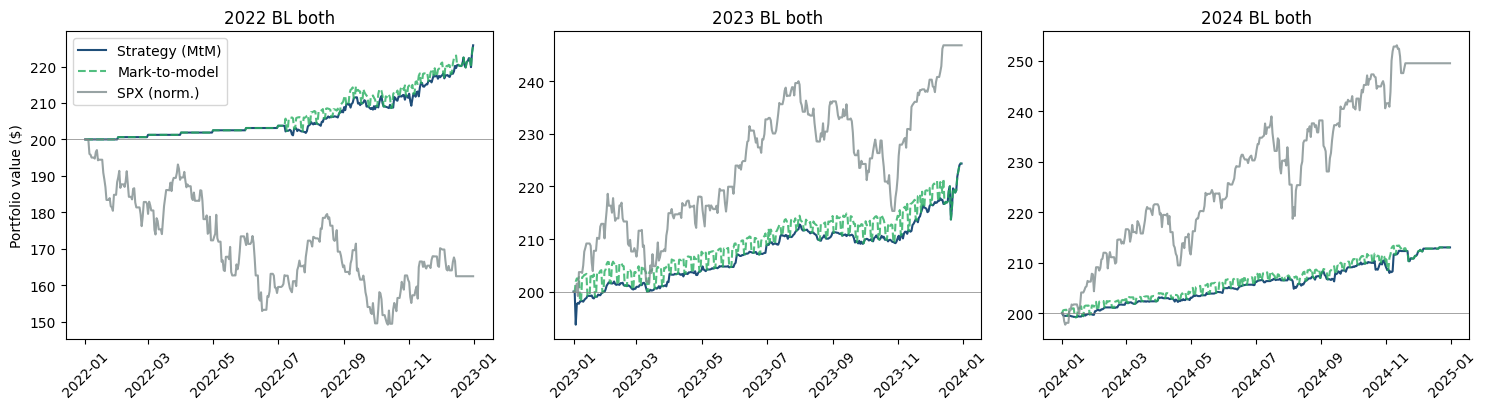

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for i, y in enumerate(config.YEARS):
    m = results[(y, 'bl', 'both')]
    spx = metrics.spx_benchmark(chain, y, m.index); spx = config.START_CASH * spx / spx.iloc[0]
    ax[i].plot(m.index, m['portfolio_value'], color='#1f4e79', label='Strategy (MtM)')
    ax[i].plot(m.index, m['model_value'], color='#27ae60', ls='--', alpha=0.8, label='Mark-to-model')
    ax[i].plot(spx.index, spx, color='#7f8c8d', alpha=0.8, label='SPX (norm.)')
    ax[i].axhline(config.START_CASH, color='grey', lw=0.5); ax[i].set_title(f'{y} BL both')
    ax[i].tick_params(axis='x', rotation=45)
    if i == 0: ax[i].legend(); ax[i].set_ylabel('Portfolio value ($)')
plt.tight_layout(); plt.savefig(config.ARTIFACT_DIR / 'equity_curves_bl.png', dpi=130, bbox_inches='tight'); plt.show()

## 5. Hedging — SPX option replication (cross-market check)
Each bucket is replicated from out-of-the-money option spreads and compared with the Kalshi book on the same day. The gap is measured mid-to-mid and after crossing every bid-ask spread. A daily-MTM hedged backtest is future work (see ASSUMPTIONS.md §7).

In [6]:
frames = [hedging.analyze_year(chain, kalshi, y) for y in config.YEARS]
for y, f in zip(config.YEARS, frames): f['year'] = y
allh = pd.concat(frames)
s = hedging.summarize_edges(allh)
print(f"mean |Kalshi - replication| = {s['mean_abs_edge']*100:.2f}c | median option round-trip spread = {s['median_option_spread']*100:.0f}c")
print(f"share with a positive edge after spreads and fee: {s['share_net_positive']*100:.1f}% | that also exceeds the replication error: {s['share_net_beats_basis']*100:.1f}%")
allh.groupby('year')[['edge','net_edge','basis']].agg(['mean','std']).round(3)

[hedge 2022] 1196 obs | mean |edge| 2.81c | executable>0 0.3% | net of fee>0 0.2% | net>basis 0.2% | option spread median 42c


[hedge 2023] 2043 obs | mean |edge| 3.33c | executable>0 6.6% | net of fee>0 5.7% | net>basis 2.1% | option spread median 23c


[hedge 2024] 1018 obs | mean |edge| 2.31c | executable>0 0.3% | net of fee>0 0.1% | net>basis 0.0% | option spread median 26c
mean |Kalshi - replication| = 2.94c | median option round-trip spread = 26c
share with a positive edge after spreads and fee: 2.8% | that also exceeds the replication error: 1.1%


edge        net_edge         basis       
       mean    std     mean    std   mean    std
year                                            
2022  0.007  0.040   -0.269  0.310  0.004  0.003
2023  0.012  0.045   -0.137  0.152  0.011  0.012
2024  0.009  0.038   -0.210  0.232  0.008  0.009